# EarlyStruct – Design Explorer (Floors)
Carbon-first feasibility & comparison tool.

**How to use**
1) Set **Data dir** to the folder containing your CSVs.
2) (Optional) Provide a **Control file** path. If present, it takes precedence for project details and SPANS unless it contains `USE_CSV = Y`.
3) (Optional) Enter **Spans** like `9, 10.5` (meters) or `28ft, 32ft`. Notebook spans override control-file SPANS.
4) Click **Run Evaluation**. If no spans are provided (and no grid_options.csv / ideal spacing), the tool runs a 1-ft sweep (18–45 ft).


In [ ]:
`# Notebook cell: robust import of your continuousslab checker + safe bar_spacing loading
import sys, os
from pathlib import Path

# --- 1) set project code root (parent of 'earlystruct') ---
CODE_ROOT = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/code")
if not CODE_ROOT.exists():
    raise FileNotFoundError(f"CODE_ROOT not found: {CODE_ROOT}")

if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

# --- 2) import the checker module from its real package path ---
try:
    # exact path must match folder names (case-sensitive)
    from earlystruct.CodeChecks import continuouslab as continuouslab_mod
except Exception as e:
    # helpful error if import fails
    raise ImportError(
        "Failed to import earlystruct.CodeChecks.continuouslab. "
        "Make sure CODE_ROOT is the parent of 'earlystruct' and that earlystruct/CodeChecks "
        "contains continuouslab.py (and __init__.py if needed). Original error: "
        + str(e)
    ) from e

# --- 3) ensure bar_spacing DataFrame exists on the module (avoid hard-coded absolute path blows up) ---
# the CSV folder normally used by your pipeline:
DEFAULT_DATA_DIR = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs")

# if the module already provided a bar_spacing DataFrame, keep it; if it has a path that doesn't exist, override
bar_spacing_ok = False
if hasattr(continuouslab_mod, "bar_spacing"):
    df_bs = getattr(continuouslab_mod, "bar_spacing")
    # treat None or empty as not ok
    if isinstance(df_bs, (pd.DataFrame,)) and not df_bs.empty:
        bar_spacing_ok = True

# try to load bar_spacing.csv from DEFAULT_DATA_DIR if needed
if not bar_spacing_ok:
    bs_path = DEFAULT_DATA_DIR / "bar_spacing.csv"
    if bs_path.exists():
        try:
            df_bs = pd.read_csv(bs_path)
            continuouslab_mod.bar_spacing = df_bs
            bar_spacing_ok = True
        except Exception as e:
            # leave bar_spacing as None and warn
            continuouslab_mod.bar_spacing = None
            print(f"Warning: failed to read {bs_path}: {e}")
    else:
        # fallback: set attribute to None so code knows it's missing
        continuouslab_mod.bar_spacing = None
        print(f"Warning: bar_spacing.csv not found at {bs_path}; continuouslab.bar_spacing set to None")

# --- 4) export the helpers for convenience ---
run_code_check_for_typology = getattr(continuouslab_mod, "run_code_check_for_typology", None)
bar_spacing = getattr(continuouslab_mod, "bar_spacing", None)
Dimensions = getattr(continuouslab_mod, "Dimensions", None)

print("Imported continuouslab:", run_code_check_for_typology is not None)
print("bar_spacing loaded:", isinstance(bar_spacing, pd.DataFrame))
print("Dimensions present:", isinstance(Dimensions, dict))


Imported continuouslab: True
bar_spacing loaded: True
Dimensions present: True


In [14]:
data_dir = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs")
control_file = "/Users/benjaminsalop/Desktop/Oxford/Research/edca/control_file/control_file.txt"

df, ranked, pareto, saved = cli.evaluate(
    data_dir=data_dir,
    spans_str=None,          # let control file + sweep logic handle it
    export_dir=None,
    control_file=control_file,
)

if isinstance(saved, dict):
    project = saved.get("project", {}) or {}
    ctl = saved.get("ctl", {}) or {}
else:
    project = {}
    ctl = {}

df.shape, df.columns

NameError: name 'cli' is not defined

In [13]:
import os, sys
from pathlib import Path

CODE_ROOT = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/code")
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from earlystruct.core.control import parse_control

control_path = "/Users/benjaminsalop/Desktop/Oxford/Research/edca/control_file/control_file.txt"

print("Exists?", os.path.exists(control_path), "->", control_path)

ctl = parse_control(control_path)
print("Parsed keys:", list(ctl.keys()))

print("PROJECT_NAME:", ctl.get("PROJECT_NAME"))
print("UNIT:", ctl.get("UNIT"))
print("FLOOR_AREA_PER_FLOOR:", ctl.get("FLOOR_AREA_PER_FLOOR"))
print("SPAN_SWEEP_FROM_MIN:", ctl.get("SPAN_SWEEP_FROM_MIN"), "BOOL:", ctl.get("SPAN_SWEEP_FROM_MIN_BOOL"))
print("ONE_WAY_IRREGULAR:", ctl.get("ONE_WAY_IRREGULAR"), "BOOL:", ctl.get("ONE_WAY_IRREGULAR_BOOL"))
print("ONE_WAY_SLAB_MIN_SPAN:", ctl.get("ONE_WAY_SLAB_MIN_SPAN"))
print("ONE_WAY_BEAM_MIN_SPAN:", ctl.get("ONE_WAY_BEAM_MIN_SPAN"))
print("PROGRAM_BLOCKS:", ctl.get("PROGRAM_BLOCKS"))


Exists? True -> /Users/benjaminsalop/Desktop/Oxford/Research/edca/control_file/control_file.txt
Parsed keys: ['USE_CSV', 'DATA_DIR', 'PROJECT_NAME', 'LOCATION', 'UNIT', 'FLOOR_AREA_PER_FLOOR', 'FLOOR_TO_FLOOR', 'NUM_FLOORS', 'IDEAL_COLUMN_SPACING', 'PLATE_LENGTH', 'PLATE_WIDTH', 'DEPTH_LIMIT_ENABLED', 'DEPTH_LIMIT', 'NOTES', 'SPANS', 'EDGE_CANTILEVER_MAX_M', 'SPAN_SWEEP_FROM_MIN', 'SPAN_SWEEP_STEP', 'LOAD_CHECK_MODE', 'RESULTS_SCOPE', 'ONE_WAY_IRREGULAR', 'ONE_WAY_SLAB_MIN_SPAN', 'ONE_WAY_BEAM_MIN_SPAN', 'FRAME_PENALTIES_ENABLED', 'FRAME_BEAM_SLENDERNESS', 'FRAME_BEAM_DEPTH_MAX', 'FRAME_BEAM_WIDTH', 'FRAME_COLUMN_WIDTH', 'FRAME_COLUMN_DEPTH', 'USE_CSV_BOOL', 'DEPTH_LIMIT_ENABLED_BOOL', 'FRAME_PENALTIES_ENABLED_BOOL', 'SPAN_SWEEP_FROM_MIN_BOOL', 'ONE_WAY_IRREGULAR_BOOL', 'PROGRAM_BLOCKS']
PROJECT_NAME: Warneford Research Building
UNIT: metric
FLOOR_AREA_PER_FLOOR: 5690.0
SPAN_SWEEP_FROM_MIN: N BOOL: False
ONE_WAY_IRREGULAR: Y BOOL: True
ONE_WAY_SLAB_MIN_SPAN: 6.6
ONE_WAY_BEAM_MIN_SPAN: 

In [15]:
UNIT = ctl.get("UNIT", "metric").lower()
is_imperial = UNIT.startswith("imp") or ("ft" in UNIT)

FT_PER_M = 3.28084

df_disp = df.copy()

if is_imperial:
    df_disp["span_slab_dir_ft"] = df_disp["span_slab_dir_m"] * FT_PER_M
    df_disp["span_beam_dir_ft"] = df_disp["span_beam_dir_m"] * FT_PER_M
else:
    df_disp["span_slab_dir_ft"] = pd.NA
    df_disp["span_beam_dir_ft"] = pd.NA

cols = [
    "system_id", "type", "feasible",
    "span_slab_dir_m", "span_beam_dir_m",
    "span_slab_dir_ft", "span_beam_dir_ft",
    "depth_m", "area_m2",
    "concrete_m3", "steel_m3", "timber_m3",
    "cost_per_m2", "carbon_per_m2",
    "cost_total", "carbon_total_kg",
]

df_disp[[c for c in cols if c in df_disp.columns]].head(15)


NameError: name 'df' is not defined

In [ ]:
best_by_type = reporting.cheapest_span_by_type(df)

best_cols = [
    "type",
    "system_id",
    "span_slab_dir_m",
    "span_beam_dir_m",
    "depth_m",
    "area_m2",
    "concrete_m3", "steel_m3", "timber_m3",
    "cost_total", "cost_per_m2",
    "carbon_total_kg", "carbon_per_m2",
]

best_by_type[[c for c in best_cols if c in best_by_type.columns]]


,type,system_id,span_slab_dir_m,span_beam_dir_m,depth_m,area_m2,concrete_m3,steel_m3,timber_m3,cost_total,cost_per_m2,carbon_total_kg,carbon_per_m2
0,composite_deck,ComFlor210_normal_weight,6.6,9.000000,0.450000,22760.0,4979.698341,1803.0472,NaN,597563.800910,26.255000,1.738911e+06,76.402050
1,double_tee,pci_dt_12DT28,9.0,12.272727,0.838200,22760.0,3562.077939,1155.2976,NaN,427449.352727,18.780727,1.243878e+06,54.651916
2,hollowcore,flood_hc_150_t0,6.6,9.000000,0.450000,22760.0,3831.266659,1251.8000,NaN,459751.999090,20.200000,1.337878e+06,58.782000
3,plank,flood_super_voidslab,9.0,12.272727,0.613636,22760.0,3526.041280,1138.0000,NaN,423124.953638,18.590727,1.231294e+06,54.099016


In [ ]:
reporting.print_verbose_summary(df, project, ctl)



================ VERBOSE SUMMARY ================
Project:   Warneford Research Building
Location:  Warneford Ln, Headington, Oxford OX3 7JX
Units:     metric
Floor area per floor: 5690.0
Number of floors:     5

Frame (beam/column) penalties: ENABLED
  Beam slenderness L/d:     20.0
  Beam width (control units):    0.2
  Column width (control units):  0.3
  Column depth (control units):  0.3
  Max beam depth (control units): 0.8

Best option (by carbon_per_m2, then cost_per_m2):
  System:     flood_super_voidslab  (plank)
  Category:   precast, type: plank
  Span (slab dir):  9.000 m
  Span (beam dir):  12.273 m
  Structural depth: 0.614 m
  Slab depth:       0.250 m
  Beam depth:       0.614 m

Carbon split (per m²):
  Floor (slab only):       36.375 kgCO2/m²
  Beams:                   16.508 kgCO2/m²
  Columns:                  1.216 kgCO2/m²
  Frame (beams+cols):      17.724 kgCO2/m²
  TOTAL (used in optimisation):     54.099 kgCO2/m²

Carbon split (totals over analysed area):
  A

In [ ]:
def prepare_for_plots(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # Ensure feasible is boolean
    if "feasible" in df.columns:
        if df["feasible"].dtype == object:
            df["feasible"] = df["feasible"].astype(str).str.strip().str.upper().map(
                {"Y": True, "YES": True, "TRUE": True, "T": True, "1": True,
                 "N": False, "NO": False, "FALSE": False, "0": False}
            ).fillna(False)
        else:
            try:
                df["feasible"] = df["feasible"].astype(bool)
            except Exception:
                df["feasible"] = df["feasible"].fillna(False).astype(bool)
    else:
        df["feasible"] = False

    # numeric coercion for columns used in plots
    for col in ("carbon_per_m2", "cost_per_m2", "cost_total", "carbon_total_kg"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # typology convenience (if not present)
    if "typology" not in df.columns:
        df = reporting.add_typology(df)

    # ensure type and system_id are string (avoid mixed-type sort errors)
    if "type" in df.columns:
        df["type"] = df["type"].astype(str)
    if "system_id" in df.columns:
        df["system_id"] = df["system_id"].astype(str)

    return df

df_clean = prepare_for_plots(df)
print("Prepared df_clean — rows:", len(df_clean))


Prepared df_clean — rows: 308


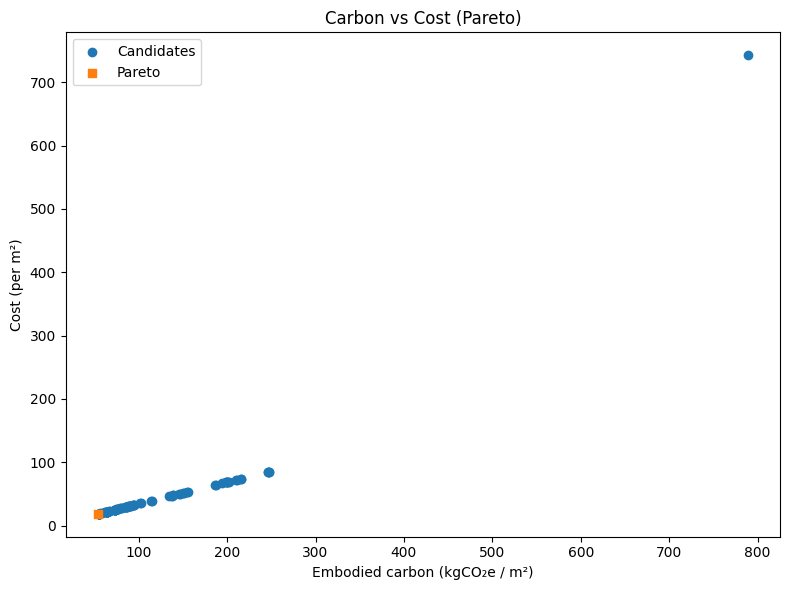

Saved: plots/pareto.png


<Figure size 640x480 with 0 Axes>

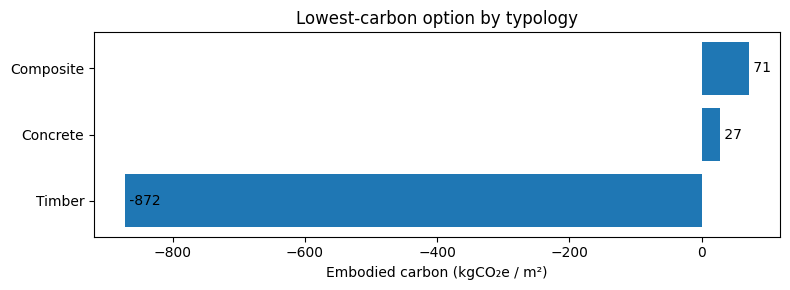

Saved: plots/best_by_typology.png


<Figure size 640x480 with 0 Axes>

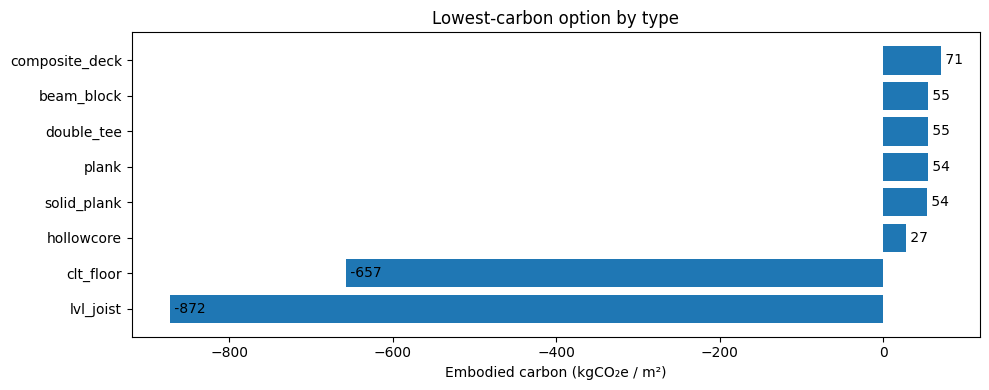

Saved: plots/best_by_type.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Use df_clean that you prepared earlier.
# After each plot call, capture the current figure and save it immediately.

plots_dir = Path(".") / "plots"
plots_dir.mkdir(exist_ok=True)

# Pareto
reporting.plot_pareto(df_clean, title="Carbon vs Cost (Pareto)")
plt.gcf().savefig(plots_dir / "pareto.png", bbox_inches="tight")
print("Saved:", plots_dir / "pareto.png")

# Best by typology (carbon)
reporting.plot_best_typology_carbon(df_clean, title="Lowest-carbon option by typology")
plt.gcf().savefig(plots_dir / "best_by_typology.png", bbox_inches="tight")
print("Saved:", plots_dir / "best_by_typology.png")

# Best by type (carbon)
reporting.plot_best_type_carbon(df_clean, title="Lowest-carbon option by type")
plt.gcf().savefig(plots_dir / "best_by_type.png", bbox_inches="tight")
print("Saved:", plots_dir / "best_by_type.png")

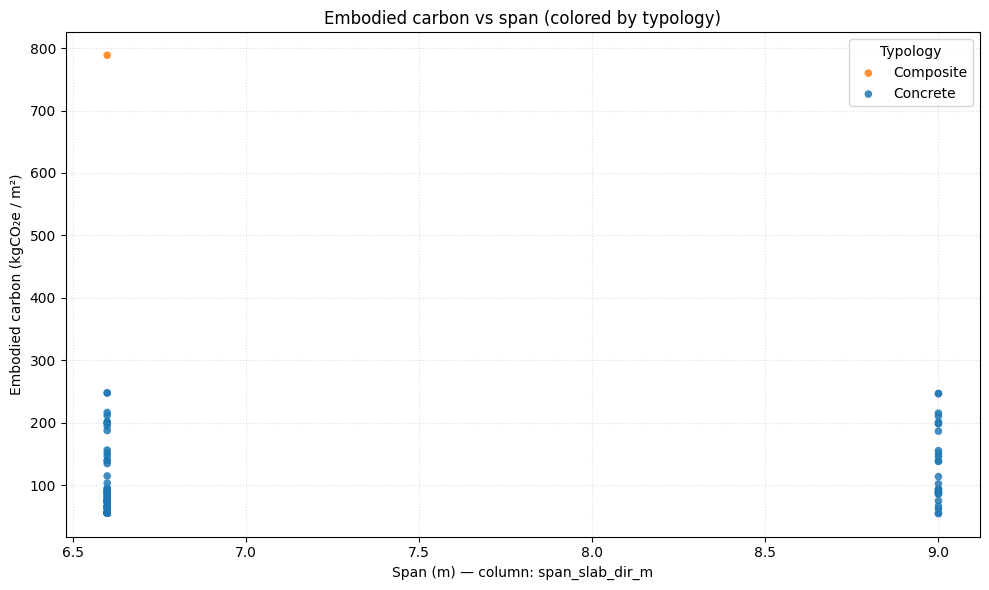

Saved: plots/carbon_vs_span.png


<Figure size 640x480 with 0 Axes>

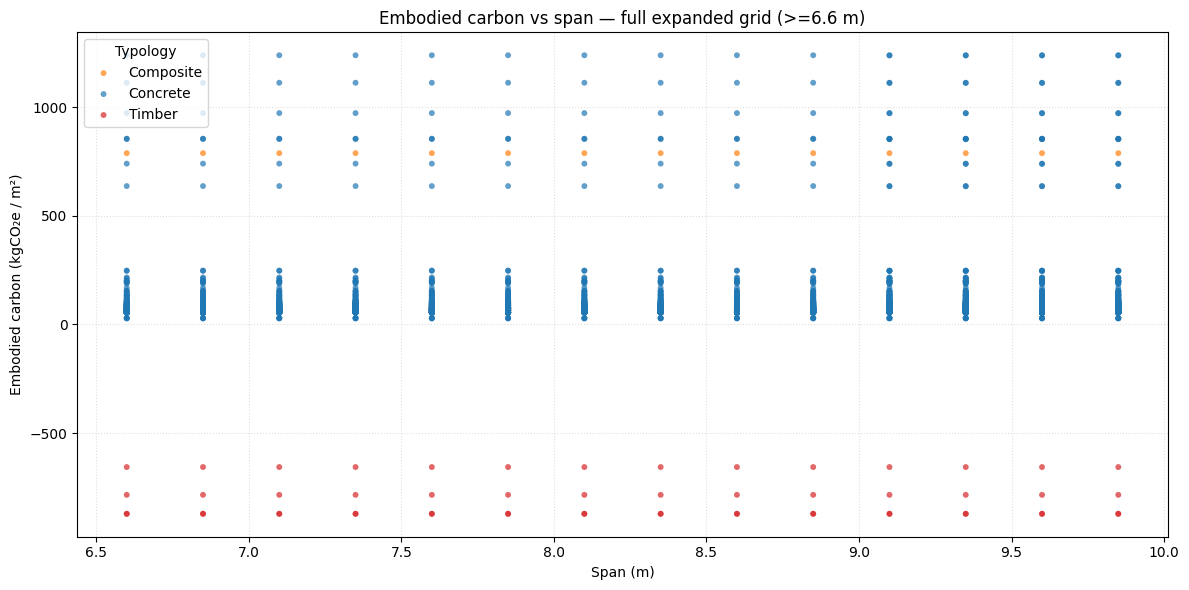

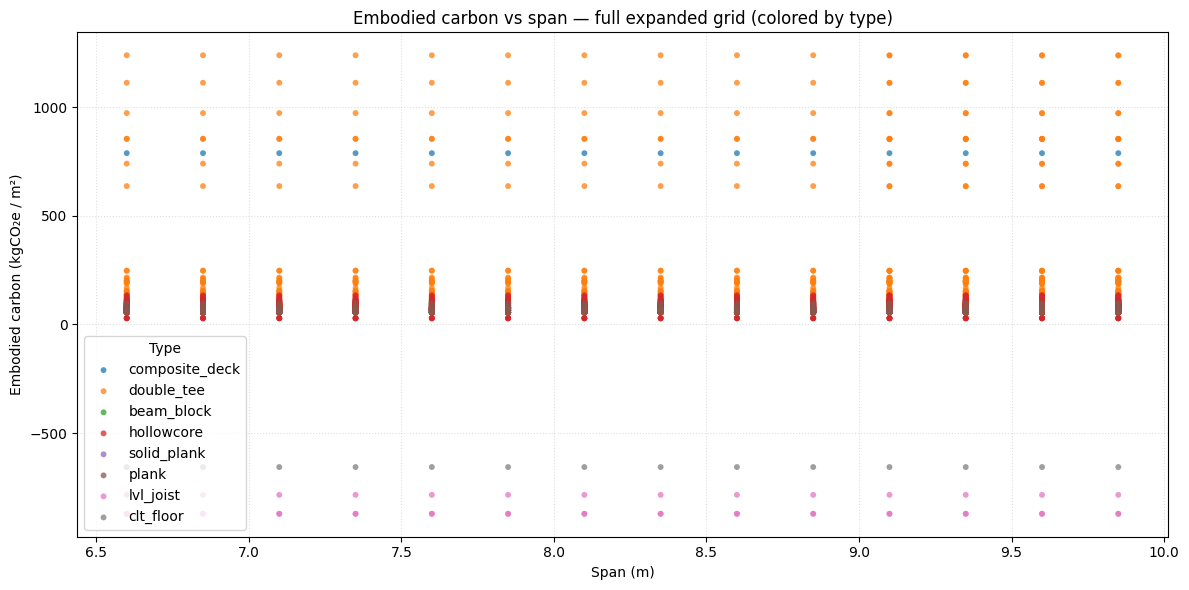

Saved: plots/carbon_vs_span_expanded.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Choose which DF to plot: df (raw), or df_clean if you prepared it earlier.
plot_df = df  # or df_clean if you prefer the cleaned version

# Minimum span threshold (None or numeric)
min_span_m = 0.0   # change to e.g. 6.6 to show only >= 6.6 m spans

# Call plot helper
reporting.plot_carbon_vs_span(
    plot_df,
    span_col="span_slab_dir_m",
    carbon_col="carbon_per_m2",
    min_span=min_span_m,
    only_feasible=True,
    title="Embodied carbon vs span (colored by typology)"
)

# Save to disk: capture current figure
out_dir = Path(".") / "plots"
out_dir.mkdir(exist_ok=True)
import matplotlib.pyplot as plt
plt.gcf().savefig(out_dir / "carbon_vs_span.png", bbox_inches="tight")
print("Saved:", out_dir / "carbon_vs_span.png")

reporting.plot_carbon_vs_span_grid(
    plot_df,
    span_min_global=6.6,
    span_max_global=10.0,   # set high enough to include all desired spans, or None to auto-infer
    step=0.25,              # quarter-meter resolution (dense)
    carbon_col="carbon_per_m2",
    only_feasible=False,    # set False to include all numeric rows regardless of feasible flag
    max_points=200000,
    title="Embodied carbon vs span — full expanded grid (>=6.6 m)"
)

# Plot the full expanded grid, colored by `type` (use only_feasible=False to show whole catalog)
reporting.plot_carbon_vs_span_grid_types(df, span_min_global=6.6, span_max_global=10.0, step=0.25, only_feasible=False)


# Save
out_dir = Path(".") / "plots"
out_dir.mkdir(exist_ok=True)
import matplotlib.pyplot as plt
plt.gcf().savefig(out_dir / "carbon_vs_span_expanded.png", bbox_inches="tight")
print("Saved:", out_dir / "carbon_vs_span_expanded.png")


In [ ]:
# Diagnostic: inspect span/min/max and carbon columns
import pandas as pd, numpy as np
from pathlib import Path

# Use df (the evaluated results) or the raw systems catalog if you prefer
print("rows in df:", len(df))

cols_to_check = [
    "system_id", "type", "typology", "category",
    "span_slab_dir_m", "span_beam_dir_m", "span_input_m", "span_m",
    "max_span", "max_span_m", "span_max",
    "carbon_per_m2", "carbon_total_kg", "cost_per_m2"
]

present = [c for c in cols_to_check if c in df.columns]
print("present columns checked:", present)

# Show dtypes and basic stats
print("\nDTYPES and non-null counts:")
print(df[present].dtypes)
print("\ncarbon_per_m2 stats (coerced to numeric):")
cnum = pd.to_numeric(df.get("carbon_per_m2"), errors="coerce")
print("  non-null:", cnum.notna().sum(), "min/median/max:", cnum.min(), cnum.median(), cnum.max())

# Show rows with extreme carbon values
print("\nRows with carbon_per_m2 > 5000 or < 0 (possible bad values):")
display(df.loc[(cnum > 5000) | (cnum < 0), present].head(20))

# Build row_min and row_max used by plotting (same logic as plotting)
def infer_row_min(row):
    for c in ("span_slab_dir_m","span_input_m","span_m","span_x_m","span_y_m"):
        if c in row.index:
            v = pd.to_numeric(row.get(c), errors="coerce")
            if not pd.isna(v):
                return v
    return float("nan")

def infer_row_max(row):
    for c in ("max_span","max_span_m","span_max"):
        if c in row.index:
            v = pd.to_numeric(row.get(c), errors="coerce")
            if not pd.isna(v):
                return v
    return float("nan")

sample = df.head(40).copy()
sample["_row_min"] = sample.apply(infer_row_min, axis=1)
sample["_row_max"] = sample.apply(infer_row_max, axis=1)
sample["_carbon_numeric"] = pd.to_numeric(sample.get("carbon_per_m2"), errors="coerce")
print("\nSample first 40 rows with inferred min/max/carbon:")
display(sample[["system_id","type","_row_min","_row_max","_carbon_numeric"]].head(40))


rows in df: 308
present columns checked: ['system_id', 'type', 'category', 'span_slab_dir_m', 'span_beam_dir_m', 'span_input_m', 'span_m', 'carbon_per_m2', 'carbon_total_kg', 'cost_per_m2']

DTYPES and non-null counts:
system_id           object
type                object
category            object
span_slab_dir_m    float64
span_beam_dir_m    float64
span_input_m       float64
span_m             float64
carbon_per_m2      float64
carbon_total_kg    float64
cost_per_m2        float64
dtype: object

carbon_per_m2 stats (coerced to numeric):
  non-null: 308 min/median/max: -871.9979999999998 78.84750812361818 1239.5144998836001

Rows with carbon_per_m2 > 5000 or < 0 (possible bad values):


,system_id,type,category,span_slab_dir_m,span_beam_dir_m,span_input_m,span_m,carbon_per_m2,carbon_total_kg,cost_per_m2
172,kerto_sbeam_joist_45x360_c400_glued,lvl_joist,timber,6.6,9.0,6.6,9.0,-784.79820,-1.786201e+07,1652.4
173,kerto_sbeam_joist_51x400_c400,lvl_joist,timber,6.6,9.0,6.6,9.0,-871.99800,-1.984667e+07,1836.0
174,kerto_sbeam_joist_51x400_c400_glued,lvl_joist,timber,6.6,9.0,6.6,9.0,-871.99800,-1.984667e+07,1836.0
175,klh_floor_7ss_280mm_tl,clt_floor,timber,6.6,9.0,6.6,9.0,-656.74896,-1.494761e+07,891.8



Sample first 40 rows with inferred min/max/carbon:


,system_id,type,_row_min,_row_max,_carbon_numeric
0,ComFlor100_normal_weight,composite_deck,6.6,NaN,788.658292
1,ComFlor210_normal_weight,composite_deck,6.6,NaN,76.402050
2,DuraStress_12DT24_2in_top,double_tee,6.6,NaN,199.390190
3,DuraStress_12DT24_no_top,double_tee,6.6,NaN,139.183293
4,DuraStress_12DT26_no_top,double_tee,6.6,NaN,146.408121
5,DuraStress_12DT28_2in_top,double_tee,6.6,NaN,211.431569
6,DuraStress_12DT28_no_top,double_tee,6.6,NaN,151.224672
7,DuraStress_12DT28_pretop,double_tee,6.6,NaN,194.573638
8,DuraStress_12DT30_pretop,double_tee,6.6,NaN,201.798466
9,DuraStress_8DT10_2in_top,double_tee,6.6,NaN,168.082603


Rows plotted (df_disp scatter): 308


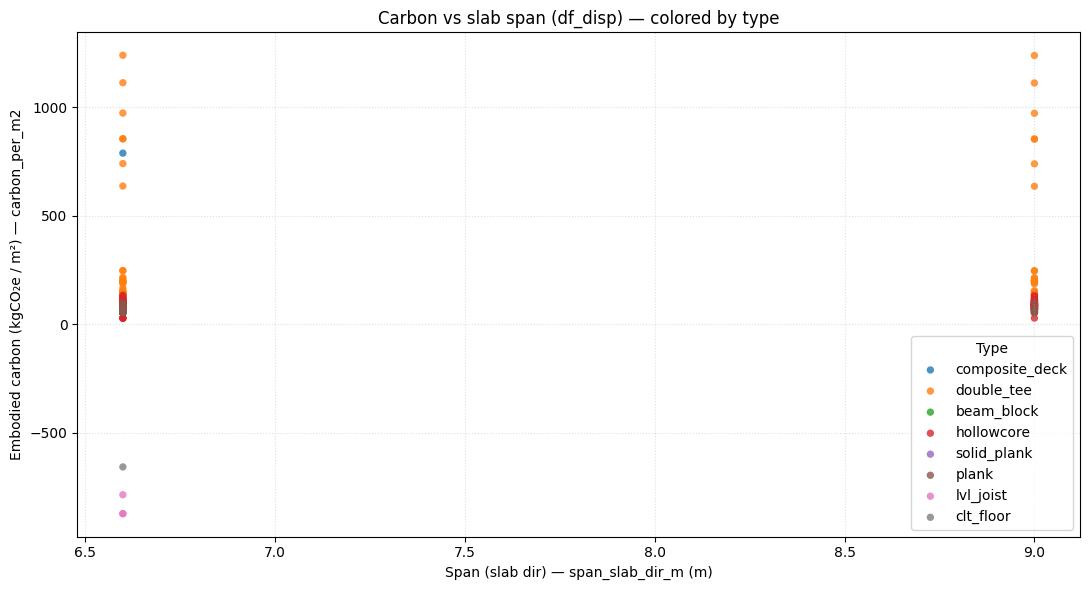

In [ ]:
# Cell A: simple scatter using df_disp
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# df_disp should already exist in your notebook (from earlier)
if "df_disp" not in globals():
    print("df_disp not found — make sure you ran the earlier cells that create it (df_disp = df.copy() etc.)")
else:
    D = df_disp.copy()

    # Ensure columns exist
    if "span_slab_dir_m" not in D.columns:
        raise RuntimeError("Column 'span_slab_dir_m' not found in df_disp.")
    if "carbon_per_m2" not in D.columns:
        raise RuntimeError("Column 'carbon_per_m2' not found in df_disp.")
    if "type" not in D.columns:
        D["type"] = D.get("typology", "Unknown")

    # coerce numeric
    D["_span"] = pd.to_numeric(D["span_slab_dir_m"], errors="coerce")
    D["_carbon"] = pd.to_numeric(D["carbon_per_m2"], errors="coerce")

    # drop rows missing numeric span or carbon
    plot_df = D.loc[D["_span"].notna() & D["_carbon"].notna()].copy()
    print("Rows plotted (df_disp scatter):", len(plot_df))

    # color by 'type'
    types = list(pd.unique(plot_df["type"].astype(str)))
    colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", None)
    if not colors:
        colors = ["C%d" % i for i in range(10)]
    color_map = {t: colors[i % len(colors)] for i, t in enumerate(types)}

    fig, ax = plt.subplots(figsize=(11,6))
    for t in types:
        sub = plot_df[plot_df["type"].astype(str) == t]
        if sub.empty:
            continue
        ax.scatter(sub["_span"], sub["_carbon"], s=28, alpha=0.8, label=str(t), c=color_map.get(t), edgecolors="none")

    ax.set_xlabel("Span (slab dir) — span_slab_dir_m (m)")
    ax.set_ylabel("Embodied carbon (kgCO₂e / m²) — carbon_per_m2")
    ax.set_title("Carbon vs slab span (df_disp) — colored by type")
    ax.grid(True, linestyle=":", alpha=0.4)

    # Legend handling: if many types, place legend outside
    if len(types) <= 20:
        ax.legend(title="Type", loc="best")
    else:
        ax.legend(title="Type", bbox_to_anchor=(1.02,1), loc="upper left", ncol=1)
        plt.subplots_adjust(right=0.75)

    plt.tight_layout()
    plt.show()


Rows plotted (catalog scatter): 7036

[validator] Suspicious spans (top 30 by span):


,system_id,type,unit,max_span,_is_imperial,_max_span_m,manufacturer,span_behavior
2088,Wells_DT3210,double_tee,imperial,105.0,True,32.004,Wells,one-way


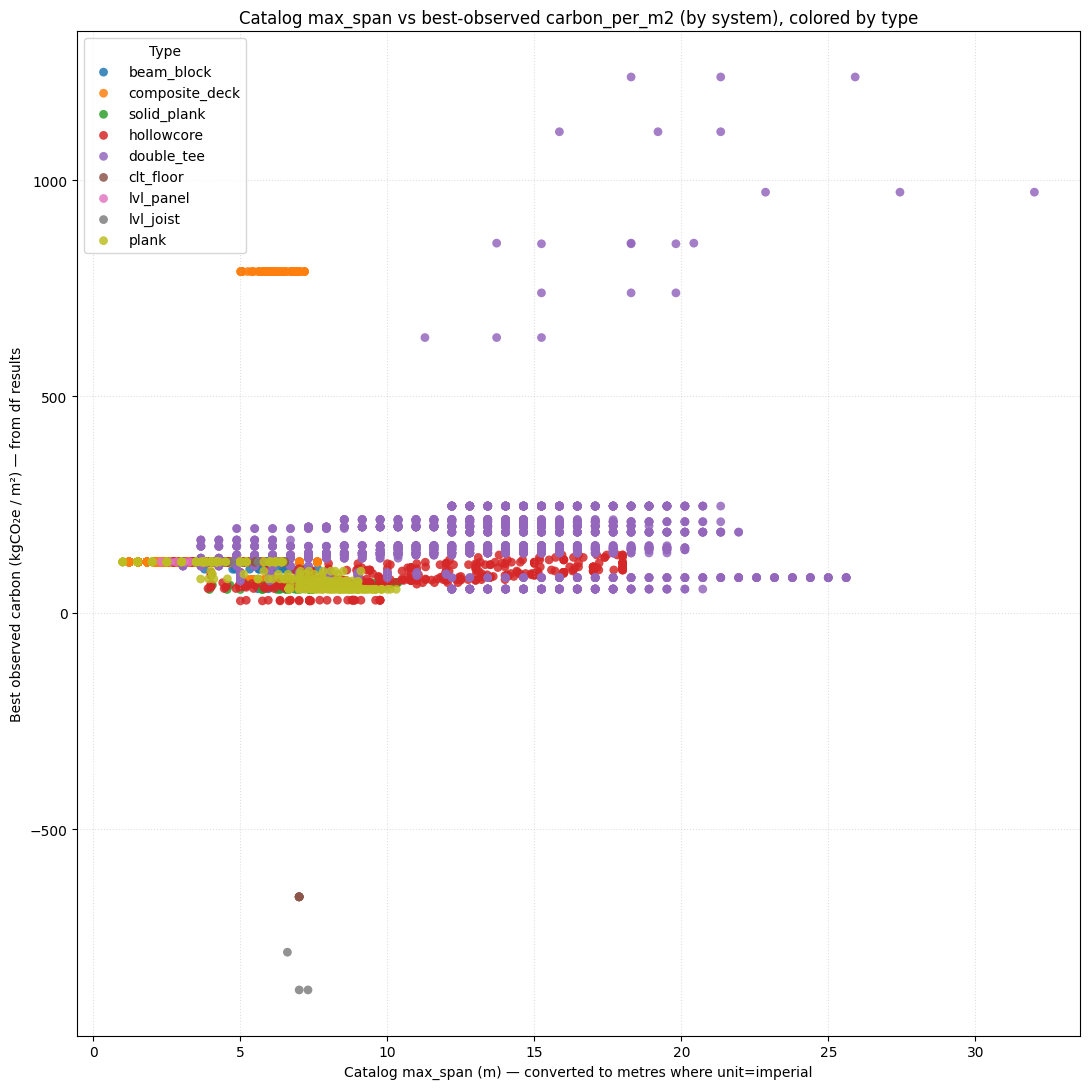

In [ ]:
# Corrected Cell B: catalog-based scatter using systems_catalog.max_span and df results
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

catalog_csv = Path("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs/systems_catalog.csv")
if not catalog_csv.exists():
    raise RuntimeError("systems_catalog.csv not found at: " + str(catalog_csv))

systems = pd.read_csv(catalog_csv)

# sanity checks
if "system_id" not in systems.columns:
    raise RuntimeError("systems_catalog.csv missing 'system_id' column.")
if "max_span" not in systems.columns:
    raise RuntimeError("systems_catalog.csv missing 'max_span' column (required).")

# ------------------------------
# NEW: normalize spans to metres
# ------------------------------
def _unit_is_imperial(u) -> bool:
    s = str(u).strip().lower()
    # treat these as imperial; everything else defaults to metric
    return (
        s.startswith("imp")
        or s in {"imperial", "us", "us customary", "usc", "imperial (ft)", "ft", "feet"}
        or "imperial" in s
        or "ft" in s
    )

systems = systems.copy()
systems["_max_span_num_raw"] = pd.to_numeric(systems["max_span"], errors="coerce")
unit_series = systems["unit"].astype(str) if "unit" in systems.columns else pd.Series("metric", index=systems.index)

feet_to_m = 0.3048
systems["_is_imperial"] = unit_series.map(_unit_is_imperial)
systems["_max_span_m"] = np.where(
    systems["_is_imperial"],
    systems["_max_span_num_raw"] * feet_to_m,
    systems["_max_span_num_raw"]
)

# ------------------------------
# pull best-observed carbon from df/df_disp
# ------------------------------
# Get df source safely from globals
if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
    df_source = globals()["df"]
elif "df_disp" in globals() and isinstance(globals()["df_disp"], pd.DataFrame):
    df_source = globals()["df_disp"]
else:
    raise RuntimeError("No df or df_disp DataFrame found in notebook. Run the evaluation cell first to produce df.")

# Ensure system_id in df_source (case-insensitive fallback)
if "system_id" not in df_source.columns:
    lower_map = {c.lower(): c for c in df_source.columns}
    if "system_id" in lower_map:
        df_source = df_source.rename(columns={lower_map["system_id"]: "system_id"})
    else:
        raise RuntimeError("df does not contain a 'system_id' column — cannot map results to systems_catalog.")

# Coerce numeric carbon
df_source = df_source.copy()
df_source["_carbon_num"] = pd.to_numeric(df_source.get("carbon_per_m2"), errors="coerce")

# Build best-observed carbon per system (minimum across rows)
best_by_system = (
    df_source.loc[df_source["_carbon_num"].notna()]
             .groupby("system_id", as_index=True)["_carbon_num"]
             .min()
             .rename("carbon_best_per_m2")
             .reset_index()
)

# Merge with catalog on system_id
merged = systems.merge(best_by_system, how="left", on="system_id")

# Fallback carbon if missing (use overall mean of df_source if available)
fallback_carbon = df_source["_carbon_num"].mean() if df_source["_carbon_num"].notna().any() else np.nan
merged["carbon_best_per_m2"] = merged["carbon_best_per_m2"].fillna(fallback_carbon)

# Choose type column if present
type_col = "type" if "type" in systems.columns else None
if type_col is None:
    merged["type"] = merged.get("category", "Unknown")
    type_col = "type"

# Filter plot rows
plot_df = merged.loc[merged["_max_span_m"].notna() & merged["carbon_best_per_m2"].notna()].copy()
print("Rows plotted (catalog scatter):", len(plot_df))

# -----------------------------------
# NEW: lightweight validator warnings
# -----------------------------------
# Soft caps — feel free to tweak
soft_caps_m = {
    "hollowcore": 18.0,
    "double_tee": 30.0,
    "composite_deck": 15.0,
    "solid_plank": 12.0,
    "clt_floor": 12.0,
    "lvl_panel": 15.0,
    "lvl_joist": 12.0,
    "beam_block": 8.0,
    "plank": 12.0,
}

def _flag_row(r):
    t = str(r.get(type_col, "")).lower()
    cap = soft_caps_m.get(t, None)
    too_big_vs_type = (cap is not None) and (r["_max_span_m"] > cap)
    too_big_global = r["_max_span_m"] > 40.0
    return too_big_vs_type or too_big_global

flags = plot_df.loc[plot_df.apply(_flag_row, axis=1)]
if not flags.empty:
    # Show the worst offenders
    cols_to_show = ["system_id", type_col, "unit", "max_span", "_is_imperial", "_max_span_m", "manufacturer", "span_behavior"]
    cols_to_show = [c for c in cols_to_show if c in flags.columns]
    print("\n[validator] Suspicious spans (top 30 by span):")
    display(flags.sort_values("_max_span_m", ascending=False).head(30)[cols_to_show])
else:
    print("\n[validator] No spans exceeded soft caps or 40 m global threshold.")

# ------------------------------
# Plot (now using metres)
# ------------------------------
# Build color mapping from matplotlib default cycle
types = list(pd.unique(plot_df[type_col].astype(str)))
default_colors = plt.rcParams.get("axes.prop_cycle").by_key().get("color", None)
if not default_colors:
    default_colors = ["C%d" % i for i in range(10)]
color_map = {t: default_colors[i % len(default_colors)] for i, t in enumerate(types)}

fig, ax = plt.subplots(figsize=(11, 11))
for t in types:
    sub = plot_df[plot_df[type_col].astype(str) == t]
    if sub.empty:
        continue
    ax.scatter(
        sub["_max_span_m"],
        sub["carbon_best_per_m2"],
        s=40, alpha=0.85, label=str(t),
        c=color_map.get(t), edgecolors="none"
    )

ax.set_xlabel("Catalog max_span (m) — converted to metres where unit=imperial")
ax.set_ylabel("Best observed carbon (kgCO₂e / m²) — from df results")
ax.set_title("Catalog max_span vs best-observed carbon_per_m2 (by system), colored by type")
ax.grid(True, linestyle=":", alpha=0.4)

if len(types) <= 20:
    ax.legend(title="Type", loc="best")
else:
    ax.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.subplots_adjust(right=0.75)

plt.tight_layout()
plt.show()

                               system_id  optimized_span_m  \
174  kerto_sbeam_joist_51x400_c400_glued          9.000000   
173        kerto_sbeam_joist_51x400_c400          9.000000   
172  kerto_sbeam_joist_45x360_c400_glued          9.000000   
175               klh_floor_7ss_280mm_tl          9.000000   
40                          bison_hc_150          9.000000   
41                    bison_hc_150_sound          9.000000   
43                          bison_hc_250         12.272727   
42                          bison_hc_200          9.000000   
44                          bison_sp_150          9.000000   
115    fsw_propped_100_150_250_LL2_S9.00         12.272727   

     optimized_carbon_per_m2  
174              -871.998000  
173              -871.998000  
172              -784.798200  
175              -656.748960  
40                 27.351124  
41                 28.816779  
43                 28.859093  
42                 29.029965  
44                 53.689500  
115    

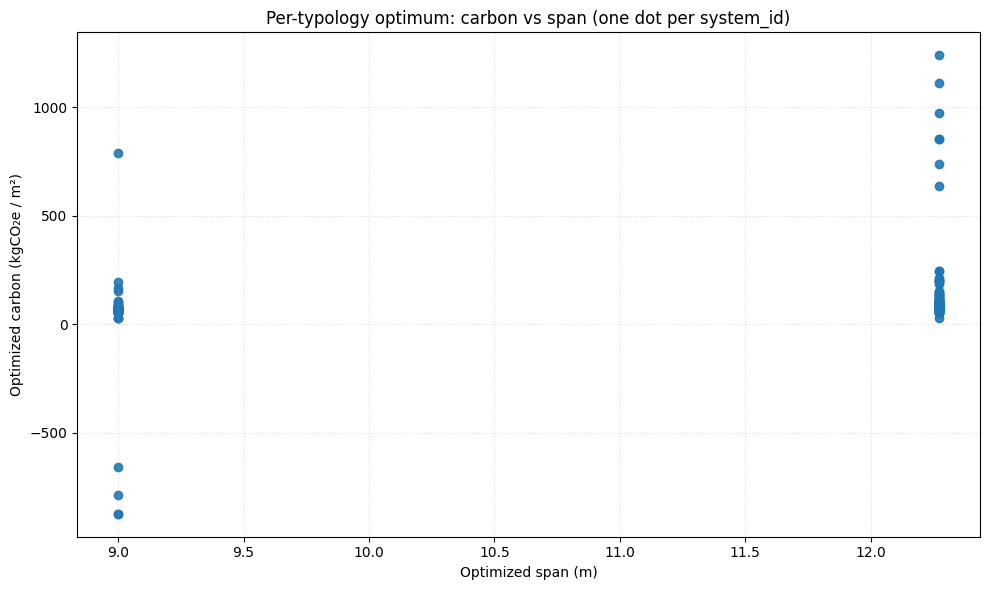

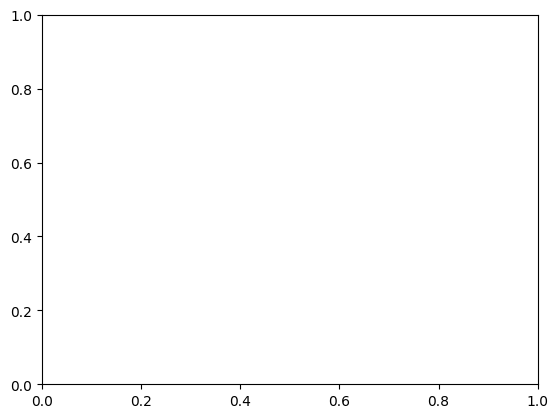

In [ ]:
# Per-typology optimum: one dot per system_id (optimized carbon vs optimized span)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# --- Pull the evaluation results from your notebook session ---
# Expecting the evaluation cell already produced a DataFrame named `df` (or `df_disp`)
if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
    df_source = globals()["df"].copy()
elif "df_disp" in globals() and isinstance(globals()["df_disp"], pd.DataFrame):
    df_source = globals()["df_disp"].copy()
else:
    raise RuntimeError(
        "No df or df_disp DataFrame found in the notebook. "
        "Run your evaluation cell first to produce df."
    )

# Ensure system_id exists (case-insensitive rescue)
if "system_id" not in df_source.columns:
    lower_map = {c.lower(): c for c in df_source.columns}
    if "system_id" in lower_map:
        df_source = df_source.rename(columns={lower_map["system_id"]: "system_id"})
    else:
        raise RuntimeError("df does not contain a 'system_id' column — cannot compute per-typology optimum.")

# Numeric carbon
df_source["_carbon_num"] = pd.to_numeric(df_source.get("carbon_per_m2"), errors="coerce")

# -------------------------------------
# Resolve a span column from df_source
# -------------------------------------
# Preference order — aims for slab-direction span if available
span_candidates = [
    "span_slab_m", "span_m", "span_slab", "slab_span_m", "slab_span",
    "span", "span (m)", "span_m_primary"
]
span_col = next((c for c in span_candidates if c in df_source.columns), None)
if span_col is None:
    span_like = [c for c in df_source.columns if "max_span" in c.lower()]
    span_like_num = [c for c in span_like if pd.to_numeric(df_source[c], errors="coerce").notna().any()]
    span_col = span_like_num[0] if span_like_num else None
if span_col is None:
    raise RuntimeError("Couldn't find a numeric span column in df (looked for: %s)" % ", ".join(span_candidates))

df_source["_span_m_raw"] = pd.to_numeric(df_source[span_col], errors="coerce")

# Gentle heuristic: if typical span looks like feet (median between ~30 and 200),
# convert to metres. (Proper unit normalization should ideally happen upstream.)
feet_to_m = 0.3048
valid_spans = df_source["_span_m_raw"].dropna()
if not valid_spans.empty and (valid_spans.median() > 30 and valid_spans.median() < 200):
    df_source["_span_m"] = df_source["_span_m_raw"] * feet_to_m
else:
    df_source["_span_m"] = df_source["_span_m_raw"]

# -------------------------------------
# Pick the best (lowest) carbon per system_id
# -------------------------------------
best_idx = (
    df_source.loc[df_source["_carbon_num"].notna() & df_source["_span_m"].notna()]
             .sort_values(["system_id", "_carbon_num"], ascending=[True, True])
             .groupby("system_id", as_index=False)
             .head(1)
             .index
)
best = (
    df_source.loc[best_idx, ["system_id", "_span_m", "_carbon_num"]]
             .rename(columns={"_span_m": "optimized_span_m", "_carbon_num": "optimized_carbon_per_m2"})
             .dropna(subset=["optimized_span_m", "optimized_carbon_per_m2"])
             .reset_index(drop=True)
)

# Quick peek at what’s being plotted
try:
    from caas_jupyter_tools import display_dataframe_to_user
    display_dataframe_to_user("Per-typology optimum (one row per system_id)", best.sort_values("optimized_carbon_per_m2"))
except Exception:
    # If not running in a CAAS notebook, just print a small sample
    print(best.sort_values("optimized_carbon_per_m2").head(10))

# -------------------------------------
# Scatter: one dot per system_id
# -------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(best["optimized_span_m"], best["optimized_carbon_per_m2"], s=36, alpha=0.9)
plt.xlabel("Optimized span (m)")
plt.ylabel("Optimized carbon (kgCO₂e / m²)")
plt.title("Per-typology optimum: carbon vs span (one dot per system_id)")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

# Optional: lightly annotate a few extrema to help orientation
try:
    extremes = pd.concat([
        best.nsmallest(5, "optimized_carbon_per_m2"),
        best.nlargest(5, "optimized_span_m")
    ]).drop_duplicates("system_id")
    for _, r in extremes.iterrows():
        x, y = r["optimized_span_m"], r["optimized_carbon_per_m2"]
        plt.annotate(str(r["system_id"]), (x, y), textcoords="offset points", xytext=(5,5), fontsize=8)
    plt.show()
except Exception:
    pass


In [ ]:
# Re-define wrapper with span_override support
import importlib, pandas as pd, numpy as np
from typing import Optional
continuouslab_mod = importlib.import_module("earlystruct.CodeChecks.continuouslab")

def _sanitize_bar_spacing(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    """Return a cleaned DataFrame with a single numeric 'area' column (float), sorted ascending.
       If no usable numeric column found, return None.
    """
    if df is None:
        return None
    if not isinstance(df, pd.DataFrame) or df.empty:
        return None

    # prefer columns with 'area' in the name, else try all columns
    candidates = [c for c in df.columns if 'area' in c.lower()] + [c for c in df.columns if 'area' not in c.lower()]
    tried = []
    for col in candidates:
        try:
            ser = pd.to_numeric(df[col], errors='coerce').astype(float)
        except Exception:
            ser = pd.to_numeric(df[col], errors='coerce')
        ser_valid = ser[~ser.isna() & (ser > 0)]
        if len(ser_valid) > 0:
            arr = np.unique(np.sort(ser_valid.values.astype(float)))
            return pd.DataFrame({"area": arr})
        tried.append(col)

    # nothing workable found
    print(f"Warning: bar_spacing DataFrame has no usable numeric column. Tried cols: {tried}")
    return None

def run_code_check_for_typology(systems_catalog, typology_selector=None, bar_spacing_df=None, program_df=None, span_override: float | None = None):
    """
    Robust wrapper: pick system row, apply optional span_override, sanitize bar_spacing, call preserved-math,
    and return pass/fail summary.
    """
    # 1) choose typology row (same logic as before)
    if typology_selector is None:
        mask = None
        if 'category' in systems_catalog.columns:
            mask = systems_catalog['category'].astype(str).str.lower().eq('concrete')
        elif 'type' in systems_catalog.columns:
            mask = systems_catalog['type'].astype(str).str.lower().str.contains('rc|concrete', na=False)
        sel_row = systems_catalog[mask].iloc[0] if (mask is not None and mask.any()) else systems_catalog.iloc[0]
    else:
        if isinstance(typology_selector, int):
            sel_row = systems_catalog.iloc[typology_selector]
        else:
            sel_row = systems_catalog[systems_catalog.get('system_id','') == typology_selector].iloc[0]

    row_dict = sel_row.to_dict()

    # 2) program overrides
    if program_df is not None and 'system_id' in program_df.columns:
        pmatch = program_df[program_df['system_id'] == sel_row.get('system_id')]
        if len(pmatch) > 0:
            row_dict.update(pmatch.iloc[0].dropna().to_dict())

    # 3) apply span_override if provided
    if span_override is not None:
        row_dict["span"] = float(span_override)

    # 4) sanitize bar spacing (prefer explicit arg, else module attr)
    bs_candidate = bar_spacing_df if bar_spacing_df is not None else getattr(continuouslab_mod, "bar_spacing", None)
    bs_clean = _sanitize_bar_spacing(bs_candidate)
    if bs_clean is None:
        # warn but continue: checker can run without allowable bar lookup (may flag flex_ok=False)
        print("Warning: no usable bar_spacing data found; allowable reinforcement lookup will be skipped.")
    else:
        # small sanity print
        print("bar_spacing cleaned: first areas ->", bs_clean["area"].values[:8])

    # 5) call preserved-math checker with sanitized bar spacing
    if not hasattr(continuouslab_mod, "check_slab_row_preserve_math"):
        raise RuntimeError("continuouslab module does not expose check_slab_row_preserve_math")
    results = continuouslab_mod.check_slab_row_preserve_math(row_dict, bar_spacing_df=bs_clean)

    # 6) assemble pass/fail same as earlier wrapper
    dims = getattr(continuouslab_mod, "Dimensions", {}) or {}
    slab_len_default = float(row_dict.get('span', row_dict.get('max_span', dims.get('base_slab_length', 0.0))))
    defl = results.get('deflection', {})
    shear = results.get('shear', {})
    flex = results.get('flex', {})

    max_span_int = defl.get('max_span_int')
    deflection_ok = ( (max_span_int is not None) and (not (isinstance(max_span_int,float) and np.isnan(max_span_int))) and (float(max_span_int) >= slab_len_default) )

    V_rdc = shear.get('V_rdc'); V_ed_ext = shear.get('V_ed_ext')
    shear_ok = True
    if (V_rdc is not None) and (V_ed_ext is not None):
        try:
            shear_ok = float(V_rdc) >= float(V_ed_ext)
        except Exception:
            shear_ok = True

    flex_ok = (flex.get('allowable_ext_reinforcement') is not None) and (flex.get('allowable_int_reinforcement') is not None)
    pass_overall = bool(deflection_ok and shear_ok and flex_ok)

    reinforcement = {
        "As_req_ext_mm2_per_m": flex.get("required_ext_reinforcement"),
        "As_allowable_ext_mm2": flex.get("allowable_ext_reinforcement"),
        "rho_ext": flex.get("rho_ext"),
        "As_req_int_mm2_per_m": flex.get("required_int_reinforcement"),
        "As_allowable_int_mm2": flex.get("allowable_int_reinforcement"),
        "rho_int": flex.get("rho_int")
    }

    diagnostics = {
        "G_kN_m2": results.get("G_kN_m2"),
        "Q_kN_m2": results.get("Q_kN_m2"),
        "ULS_kN_m2": results.get("ULS_kN_m2"),
        "effective_depth_m": results.get("slab_effective_depth_m"),
        "deflection": defl,
        "shear": shear,
        "flex_details": flex,
        "bar_spacing_used": list(bs_clean["area"].tolist())[:10] if bs_clean is not None else None
    }

    out = {
        "system_id": sel_row.get("system_id"),
        "pass": pass_overall,
        "deflection_ok": deflection_ok,
        "shear_ok": shear_ok,
        "flex_ok": flex_ok,
        "reinforcement": reinforcement,
        "diagnostics": diagnostics
    }
    return out

# bind into module & notebook globals
setattr(continuouslab_mod, "run_code_check_for_typology", run_code_check_for_typology)
run_code_check_for_typology = run_code_check_for_typology
print("Wrapper updated: sanitizes bar_spacing and accepts span_override.")

Wrapper updated: sanitizes bar_spacing and accepts span_override.


In [5]:
my_bs = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs/bar_spacing.csv")
systems_catalog = pd.read_csv("/Users/benjaminsalop/Desktop/Oxford/Research/edca/csvs/systems_catalog.csv")

# use the chosen row from ranked/df to get the optimizer span
chosen_span = float(chosen_row["span_slab_dir_m"])   # or span_input_m
out = run_code_check_for_typology(systems_catalog, typology_selector=chosen_system_id, bar_spacing_df=my_bs, span_override=chosen_span)
print_code_check_summary(out)


NameError: name 'chosen_row' is not defined

In [6]:
def print_code_check_summary(result: dict):
    if not result:
        print("No result")
        return
    sid = result.get("system_id","<unknown>")
    ok = result.get("pass", False)
    print(f"=== Eurocode check for {sid} ===")
    print("Overall:", "PASS ✅" if ok else "FAIL ❌")
    print("Checks:")
    print(" - Deflection:", "OK" if result.get("deflection_ok") else "FAIL")
    print(" - Shear:     ", "OK" if result.get("shear_ok") else "FAIL")
    print(" - Flexural:  ", "OK" if result.get("flex_ok") else "FAIL")
    print("\nReinforcement (mm² per m):")
    r = result.get("reinforcement", {})
    print(f"  External required: {r.get('As_req_ext_mm2_per_m')}, allowable: {r.get('As_allowable_ext_mm2')}, rho_ext: {r.get('rho_ext')}")
    print(f"  Internal required: {r.get('As_req_int_mm2_per_m')}, allowable: {r.get('As_allowable_int_mm2')}, rho_int: {r.get('rho_int')}")
    print("\nKey diagnostics (ULS, G, Q, effective depth):")
    d = result.get("diagnostics", {})
    print(f"  G={d.get('G_kN_m2')}, Q={d.get('Q_kN_m2')}, ULS={d.get('ULS_kN_m2')}")
    print(f"  effective_depth_m={d.get('effective_depth_m')}")
    # small deflection summary
    defl = d.get("deflection", {})
    if defl:
        print(f"  max_span_int (from l/d): {defl.get('max_span_int')}")
    # shear details
    shear = d.get("shear", {})
    if shear:
        print(f"  V_rdc={shear.get('V_rdc')}, V_ed_ext={shear.get('V_ed_ext')}, V_rdcmin={shear.get('V_rdcmin')}")
    print("=====================")


In [7]:
# Notebook cell: wrapper that ensures length/span are filled (uses sanitized bar spacing)
import importlib, pandas as pd, numpy as np
from typing import Optional

continuouslab_mod = importlib.import_module("earlystruct.CodeChecks.continuouslab")

def _sanitize_bar_spacing(df: Optional[pd.DataFrame]) -> Optional[pd.DataFrame]:
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    candidates = [c for c in df.columns if 'area' in c.lower()] + [c for c in df.columns if 'area' not in c.lower()]
    for col in candidates:
        ser = pd.to_numeric(df[col], errors='coerce')
        ser_valid = ser[~ser.isna() & (ser > 0)]
        if len(ser_valid) > 0:
            arr = np.unique(np.sort(ser_valid.values.astype(float)))
            return pd.DataFrame({"area": arr})
    return None

def run_code_check_for_typology(systems_catalog: pd.DataFrame,
                                typology_selector: Optional[str | int] = None,
                                bar_spacing_df: pd.DataFrame | None = None,
                                program_df: pd.DataFrame | None = None,
                                span_override: float | None = None):
    """
    Wrapper that:
      - picks a system row,
      - applies program overrides,
      - injects span/length from span_override or from optimizer fields if missing,
      - sanitizes bar_spacing and calls preserved-math,
      - returns the pass/fail summary.
    """
    # --- pick row ---
    if typology_selector is None:
        mask = None
        if 'category' in systems_catalog.columns:
            mask = systems_catalog['category'].astype(str).str.lower().eq('concrete')
        elif 'type' in systems_catalog.columns:
            mask = systems_catalog['type'].astype(str).str.lower().str.contains('rc|concrete', na=False)
        sel_row = systems_catalog[mask].iloc[0] if (mask is not None and mask.any()) else systems_catalog.iloc[0]
    else:
        if isinstance(typology_selector, int):
            sel_row = systems_catalog.iloc[typology_selector]
        else:
            sel_row = systems_catalog[systems_catalog.get('system_id','') == typology_selector].iloc[0]

    # work on a dict copy so we don't mutate original DF
    row_dict = dict(sel_row.dropna().to_dict())  # starts with non-nulls; we'll overlay any blanks explicitly

    # Merge full row (including NaNs) to preserve keys but allow updates below
    full_row = sel_row.to_dict()
    for k in full_row:
        if k not in row_dict:
            row_dict[k] = full_row[k]

    # --- program overrides (if provided) ---
    if program_df is not None and 'system_id' in program_df.columns:
        pmatch = program_df[program_df['system_id'] == sel_row.get('system_id')]
        if len(pmatch) > 0:
            row_dict.update(pmatch.iloc[0].dropna().to_dict())

    # --- Decide span value to supply to checker ---
    # Priority:
    # 1) explicit span_override argument (highest)
    # 2) optimizer fields in ranked/df style if present on the systems_catalog row (span_slab_dir_m, span_input_m, span_m, span_beam_dir_m)
    # 3) existing 'span' key on the row
    # 4) 'max_span' fallback
    chosen_span = None
    if span_override is not None:
        chosen_span = float(span_override)
    else:
        # try common optimizer field names on the row
        for cand in ("span", "span_input_m", "span_m", "span_slab_dir_m", "span_beam_dir_m", "length"):
            if cand in row_dict and row_dict.get(cand) is not None and not (isinstance(row_dict.get(cand), float) and np.isnan(row_dict.get(cand))):
                try:
                    chosen_span = float(row_dict.get(cand))
                    break
                except Exception:
                    chosen_span = None
        # fallback to max_span if nothing else
        if (chosen_span is None) and ("max_span" in row_dict and row_dict.get("max_span") is not None and not (isinstance(row_dict.get("max_span"), float) and np.isnan(row_dict.get("max_span")))):
            try:
                chosen_span = float(row_dict.get("max_span"))
            except Exception:
                chosen_span = None

    # If chosen_span found, inject to the row keys the checker may look for.
    if chosen_span is not None:
        row_dict["span"] = chosen_span
        # also set length which you observed is used by some code paths
        row_dict["length"] = chosen_span
        # mirror common variants to be safe
        row_dict["span_input_m"] = chosen_span
        row_dict["span_m"] = chosen_span
        row_dict["span_slab_dir_m"] = chosen_span

    # --- sanitize bar spacing (prefer explicit arg, else module-level bar_spacing) ---
    bs_candidate = bar_spacing_df if (bar_spacing_df is not None) else getattr(continuouslab_mod, "bar_spacing", None)
    bs_clean = _sanitize_bar_spacing(bs_candidate)
    if bs_clean is None:
        print("Warning: no usable bar_spacing data found; allowable reinforcement lookup may be skipped.")
    else:
        # small confirmation
        print("bar_spacing cleaned: first areas ->", bs_clean["area"].values[:8])

    # --- call preserved-math checker ---
    if not hasattr(continuouslab_mod, "check_slab_row_preserve_math"):
        raise RuntimeError("continuouslab module does not expose check_slab_row_preserve_math")
    results = continuouslab_mod.check_slab_row_preserve_math(row_dict, bar_spacing_df=bs_clean)

    # --- assemble pass/fail summary (same as earlier) ---
    dims = getattr(continuouslab_mod, "Dimensions", {}) or {}
    slab_len_default = float(row_dict.get('span', row_dict.get('max_span', dims.get('base_slab_length', 0.0) or 0.0)))
    defl = results.get('deflection', {}) or {}
    shear = results.get('shear', {}) or {}
    flex = results.get('flex', {}) or {}

    max_span_int = defl.get('max_span_int')
    deflection_ok = False
    try:
        if max_span_int is not None and not (isinstance(max_span_int, float) and np.isnan(max_span_int)):
            deflection_ok = float(max_span_int) >= slab_len_default
    except Exception:
        deflection_ok = False

    V_rdc = shear.get('V_rdc'); V_ed_ext = shear.get('V_ed_ext')
    shear_ok = True
    if (V_rdc is not None) and (V_ed_ext is not None):
        try:
            shear_ok = float(V_rdc) >= float(V_ed_ext)
        except Exception:
            shear_ok = True

    flex_ok = (flex.get('allowable_ext_reinforcement') is not None) and (flex.get('allowable_int_reinforcement') is not None)
    pass_overall = bool(deflection_ok and shear_ok and flex_ok)

    reinforcement = {
        "As_req_ext_mm2_per_m": flex.get("required_ext_reinforcement"),
        "As_allowable_ext_mm2": flex.get("allowable_ext_reinforcement"),
        "rho_ext": flex.get("rho_ext"),
        "As_req_int_mm2_per_m": flex.get("required_int_reinforcement"),
        "As_allowable_int_mm2": flex.get("allowable_int_reinforcement"),
        "rho_int": flex.get("rho_int")
    }

    diagnostics = {
        "G_kN_m2": results.get("G_kN_m2"),
        "Q_kN_m2": results.get("Q_kN_m2"),
        "ULS_kN_m2": results.get("ULS_kN_m2"),
        "effective_depth_m": results.get("slab_effective_depth_m"),
        "deflection": defl,
        "shear": shear,
        "flex_details": flex,
        "bar_spacing_used": list(bs_clean["area"].tolist())[:10] if bs_clean is not None else None,
        "span_used_m": slab_len_default
    }

    out = {
        "system_id": sel_row.get("system_id"),
        "pass": pass_overall,
        "deflection_ok": deflection_ok,
        "shear_ok": shear_ok,
        "flex_ok": flex_ok,
        "reinforcement": reinforcement,
        "diagnostics": diagnostics
    }
    return out

# bind into module & notebook globals
setattr(continuouslab_mod, "run_code_check_for_typology", run_code_check_for_typology)
run_code_check_for_typology = run_code_check_for_typology
print("Wrapper updated: span/length injection enabled.")


Wrapper updated: span/length injection enabled.


In [8]:
# Run this cell to dump everything used by the check for a given typology (hand-check friendly)
import importlib, pandas as pd, json, numpy as np, math
continuouslab_mod = importlib.import_module("earlystruct.CodeChecks.continuouslab")

def debug_print_typology(systems_catalog: pd.DataFrame, typology_selector=None, bar_spacing_df=None, program_df=None):
    # choose row (same logic as wrapper)
    if typology_selector is None:
        mask = None
        if 'category' in systems_catalog.columns:
            mask = systems_catalog['category'].astype(str).str.lower().eq('concrete')
        elif 'type' in systems_catalog.columns:
            mask = systems_catalog['type'].astype(str).str.lower().str.contains('rc|concrete', na=False)
        sel_row = systems_catalog[mask].iloc[0] if (mask is not None and mask.any()) else systems_catalog.iloc[0]
    else:
        sel_row = systems_catalog.iloc[typology_selector] if isinstance(typology_selector, int) else systems_catalog[systems_catalog.get('system_id','') == typology_selector].iloc[0]

    row_dict = sel_row.to_dict()
    print("=== RAW systems_catalog row (inputs from CSV) ===")
    print(json.dumps(row_dict, indent=2, default=str))

    # program overrides shown if provided
    if program_df is not None and 'system_id' in program_df.columns:
        pm = program_df[program_df['system_id'] == sel_row.get('system_id')]
        if len(pm) > 0:
            print("\n=== program.csv overrides (found) ===")
            print(json.dumps(pm.iloc[0].dropna().to_dict(), indent=2, default=str))

    # sanitize bar spacing (reuse sanitiser used earlier)
    def _sanitize(df):
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            return None
        # look for numeric candidate columns
        area_cols = [c for c in df.columns if 'area' in c.lower()] or list(df.columns)
        for c in area_cols:
            s = pd.to_numeric(df[c], errors='coerce')
            s_valid = s[~s.isna() & (s>0)]
            if len(s_valid)>0:
                arr = np.unique(np.sort(s_valid.values.astype(float)))
                return pd.DataFrame({"area": arr})
        return None

    bs = bar_spacing_df if (bar_spacing_df is not None) else getattr(continuouslab_mod, "bar_spacing", None)
    bs_clean = _sanitize(bs)
    print("\n=== bar_spacing used (cleaned) ===")
    if bs_clean is None:
        print("  NONE (no usable bar spacing).")
    else:
        print("  sample areas (mm^2 per m or units from your CSV):", bs_clean['area'].values[:20])

    # Now call the preserved-math function to compute values (it returns the internal groups)
    if not hasattr(continuouslab_mod, "check_slab_row_preserve_math"):
        raise RuntimeError("Module does not export check_slab_row_preserve_math")
    results = continuouslab_mod.check_slab_row_preserve_math(row_dict, bar_spacing_df=bs_clean)

    # Print loads
    G = results.get("G_kN_m2")
    Q = results.get("Q_kN_m2")
    ULS = results.get("ULS_kN_m2")
    print("\n=== Loads ===")
    print(f"  Permanent G = {G} kN/m^2  (permanent_loading: slab_swt + screed + finishes + services)")
    print(f"  Variable  Q = {Q} kN/m^2  (variable_loading: live + partitions)")
    print(f"  ULS (used) = {ULS} kN/m^2  (ultimate_loading formula returned)")

    # Slab geometry
    eff_depth = results.get("slab_effective_depth_m")
    flex = results.get("flex", {})
    # some intermediate values are inside flex dict already
    print("\n=== Geometry ===")
    print(f"  slab_depth (from row or system_curves): {float(row_dict.get('slab_depth', continuouslab_mod.Dimensions.get('base_slab_depth')))} m")
    print(f"  d_bar (Properties['d_bar']) = {continuouslab_mod.Properties.get('d_bar')} m")
    # If slab_dimensions returned, we can compute nominal_cover and a1/a2 again (but check function printed them)
    # The function returns effective depth; compute nominal_cover (for transparency)
    nominal_cover = max(continuouslab_mod.Properties.get('d_bar'), continuouslab_mod.Dimensions.get('base_environmental_cover')) + continuouslab_mod.Dimensions.get('base_deviation_allowance')
    print(f"  nominal_cover (used for effective depth) = max(d_bar,base_environmental_cover)+deviation = {nominal_cover} m")
    print(f"  effective_depth (from check result) = {eff_depth} m")
    # show span used
    span_used = row_dict.get('span', row_dict.get('max_span', continuouslab_mod.Dimensions.get('base_slab_length')))
    print(f"  span used for checks = {span_used} m")

    # Flexural internals (k, z, moments, shears, As)
    print("\n=== Flexural internals (exact algebra preserved) ===")
    keys = ["k","z","z_d","end_moment","internal_moment","external_shear","support_shear",
            "required_ext_reinforcement","allowable_ext_reinforcement","rho_ext","rho_0",
            "required_int_reinforcement","allowable_int_reinforcement","rho_int"]
    for k in keys:
        v = flex.get(k)
        if v is None:
            continue
        print(f"  {k} = {v}  {'(units: see notes below)' if k in ['k','z','z_d'] else ''}")

    # Explain units & formulas for flex results
    print("\n  NOTES (flex formulas & units):")
    print("   - end/internal moments are computed with factors (0.086, 0.063) * w_uls * span^2, units kN·m/m (per metre width).")
    print("   - z in metres (internal lever arm).")
    print("   - required reinforcement shown in same units your XLS uses (kN·m / (z * f_ys/gamma_s)).")
    print("   - rho values are mm²/mm³-style ratios consistent with your spreadsheet algebra.")

    # Deflection
    defl = results.get("deflection", {})
    print("\n=== Deflection / l/d results ===")
    for name,val in defl.items():
        print(f"  {name} = {val}")
    if defl:
        print("  l/d allowed formulas preserved from EC2; l_d_allowable computed from N_ext etc. l_d_actual = base_slab_length / effective_depth")

    # Shear
    shear = results.get("shear", {})
    print("\n=== Shear check internals ===")
    for name,val in shear.items():
        print(f"  {name} = {val}")
    print("  (V_ed taken from flex external_shear minus depth*a1*ultimate_load if that was used in your algebra)")

    # Full nested flex dict in JSON (for copy/paste into spreadsheet)
    print("\n\n=== FULL BLOCKS (copy/paste as JSON to your XLS) ===")
    print("flex JSON:")
    print(json.dumps(flex, indent=2, default=float))
    print("\ndeflection JSON:")
    print(json.dumps(defl, indent=2, default=float))
    print("\nshear JSON:")
    print(json.dumps(shear, indent=2, default=float))

    # extra: helpful sanity checks that often cause "suspicious" results
    print("\n=== Sanity checks & likely causes of FAIL ===")
    # check very small effective depth
    try:
        if eff_depth is not None and float(eff_depth) < 0.1:
            print("  * effective_depth is VERY small (<0.1 m). That will massively reduce l/d and shear capacity.")
            print("    -> Check your slab_depth, nominal cover, and d_bar values in systems_catalog or in Dimensions/Properties.")
    except Exception:
        pass

    # show the row values that control loads
    print("\n=== Row keys likely to affect loads and geometry (quick glance) ===")
    for k in ("slab_depth","screed_depth","sdl","ll","swt","span","max_span","material_concrete_id"):
        print(f"  {k} = {row_dict.get(k)}")

    return results

# Example usage: (replace systems_catalog variable if needed)
# results = debug_print_typology(systems_catalog, typology_selector=None, bar_spacing_df=my_bs, program_df=saved.get('program') if isinstance(saved, dict) else None)


results = debug_print_typology(systems_catalog, typology_selector=chosen_id, bar_spacing_df=my_bs, program_df=saved.get("program") if saved else None)

NameError: name 'chosen_id' is not defined

In [ ]:
mask = systems_catalog['category'].astype(str).str.lower().eq('concrete')
systems_catalog[mask & systems_catalog['slab_depth'].notna()].head(20)
systems_catalog[mask & systems_catalog['max_span'].notna()].head(20)

,component,system_id,category,type,span_behavior,manufacturer,unit,length,width,slab_depth,...,ll,max_span,material_concrete_id,material_pt_id,material_steel_id,material_timber_id,ebc_mm,beam_ref,Unnamed: 23,Unnamed: 24


In [ ]:
# prefer a feasible top-ranked system
chosen_id = None
if isinstance(ranked, pd.DataFrame) and not ranked.empty:
    if "feasible" in ranked.columns:
        fr = ranked[ranked["feasible"] == True]
        chosen_id = fr.iloc[0]["system_id"] if not fr.empty else ranked.iloc[0]["system_id"]
    else:
        chosen_id = ranked.iloc[0]["system_id"]

print("Chosen system_id:", chosen_id)


Chosen system_id: flood_super_voidslab
